# Regularization and honest validation

Runnable locally on CPU or on a Cloud TPU VM.

- Derive a ridge solution, distinguish data loss from penalized loss, and select a penalty using held-out data.
- State the exact objective
- Work through shrinkage by hand
- Keep fitting, choosing and reporting separate
- Choose which parameters to penalize

A model can fit the training data closely and still make poor predictions on new data. Can we trade a little training fit for a simpler model? We will make that tradeoff visible with a dataset small enough to solve by hand, while keeping the validation data separate from fitting.

## The idea

Regularization changes which solutions training prefers. Validation helps choose settings using data that did not fit the model, and a final test estimates performance after those choices are fixed. Keeping these jobs separate makes the reported result interpretable.

## Give each split one job

Imagine trying several penalty strengths. For each setting, fit weights on the training split, then score the frozen result on validation. Pick a setting using those validation results. Repeatedly using test performance to make that choice quietly turns the test into another validation set.

Preprocessing belongs inside the same boundary: fit means, scales and feature selection using training data only. Applying a transformation to validation is allowed; allowing validation to choose the transformation's fitted statistics changes the experiment.

The regularization plot may show training error improving while validation error worsens. That gap motivates model selection, but one small fixture does not prove a universal best penalty. Preserve split identities and the selection rule so another person can reconstruct the decision.

### Pause and reason

After selecting a penalty, you inspect the test score and change the penalty again. What has changed?

<details><summary>Compare your reasoning</summary>

The test data has influenced model selection. Its score no longer represents a single untouched final evaluation under the original protocol. Use a fresh evaluation protocol or disclose the repeated selection.

</details>

## State the exact objective

Let $n$ be the training sample count and $\lambda\ge0$ the penalty strength. We use mean squared error plus $\lambda\|w\|_2^2$, without a factor of one half. Differentiating gives $2X^\mathsf{T}(Xw-y)/n+2\lambda w$. Setting it to zero gives the linear system below. Other conventions change the numerical meaning of the same penalty value, so copy the objective along with a reported hyperparameter.

$$
L_\lambda(w)=\frac1n\|Xw-y\|_2^2+\lambda\|w\|_2^2,\qquad (X^\mathsf{T}X+n\lambda I)w=X^\mathsf{T}y
$$

## Work through shrinkage by hand

Train a slope without a bias on inputs $(-1,1)$ and targets $(-3,3)$. The data loss is $(w-3)^2$, so the ridge solution is $w=3/(1+\lambda)$. At $\lambda=0$, it fits the training slope $3$. At $\lambda=1/2$, it gives slope $2$. Our deliberately constructed validation targets follow slope $2$, making the tradeoff easy to inspect. Real validation curves are noisier and do not guarantee that positive regularization helps.

## Keep fitting, choosing and reporting separate

Fit weights on training examples for each candidate $\lambda$. Choose using validation prediction loss, not the training objective with its penalty. Validation targets must never enter the fit or preprocessing statistics. After many choices, validation itself can be overfit; a final untouched test set estimates the selected procedure. This tiny exercise has a training and validation split only, so its result is a demonstration, not a final generalization estimate.

## Choose which parameters to penalize

A bias can represent the overall target level, so many models exclude it from weight regularization. For an augmented parameter vector $(w,b)$, use a diagonal penalty mask with entries $(1,0)$. Scaling a feature also changes the size of its coefficient, and therefore the penalty. Standardize using training statistics when that matches your modeling choice, then reuse those statistics unchanged for validation and inference. Ridge adds curvature in penalized directions; it cannot repair leaked data or a wrong target.

## Create separate training and validation examples

Create main.py. Keep validation arrays separate from the solver inputs.

In [1]:
# Step 1 — Create separate training and validation examples: The helper solves the explicitly stated mean-loss convention.
# Import jax for this computation.
import jax
import jax.numpy as jnp
# Initialize array `X` with explicit values and shape.
X = jnp.array([[-1.0], [1.0]])
# Initialize array `y` with explicit values and shape.
y = jnp.array([-3.0, 3.0])
# Initialize array `Xv` with explicit values and shape.
Xv = jnp.array([[-2.0], [2.0]])
# Initialize array `yv` with explicit values and shape.
yv = jnp.array([-4.0, 4.0])

# Function `ridge(X, y, lam)` implementing this stage's computation:
def ridge(X, y, lam):
    # Return `jnp.linalg.solve(X.T @ X + X.shape[0] * lam * jnp.eye(X.shape[1]), X.T @ y)` to the caller.
    return jnp.linalg.solve(X.T @ X + X.shape[0] * lam * jnp.eye(X.shape[1]), X.T @ y)

# Function `mse(w, X, y)` implementing this stage's computation:
def mse(w, X, y):
    # Return `jnp.mean((X @ w - y) ** 2)` to the caller.
    return jnp.mean((X @ w - y) ** 2)

The helper solves the explicitly stated mean-loss convention. We use a small well-conditioned system here; this is not a general replacement for robust least-squares algorithms.

## Verify the penalized optimum

Append the hand solution and its gradient check.

In [2]:
# Step 2 — Verify the penalized optimum: The data gradient and penalty gradient cancel at w=2.
lam = 0.5
# Run `ridge` to compute `w`.
w = ridge(X, y, lam)
# Evaluate `objective` from the current inputs and state.
objective = lambda w: mse(w, X, y) + lam * jnp.dot(w, w)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(w, jnp.array([2.0]), atol=1e-06)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jax.grad(objective)(w), jnp.zeros(1), atol=1e-06)

The data gradient and penalty gradient cancel at $w=2$.

## Separate the quantities you report

Append the three losses and run python main.py.

In [3]:
# Step 3 — Separate the quantities you report: Training prediction loss is 1, validation loss is 0, and the...
train = mse(w, X, y)
# Run `mse` to compute `validation`.
validation = mse(w, Xv, yv)
# Run `objective` to compute `penalized`.
penalized = objective(w)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(jnp.array([train, validation, penalized]), jnp.array([1.0, 0.0, 3.0]))
# Print the observed values to compare against the expected result.
print('train / validation / objective:', train, validation, penalized)

train / validation / objective: 1.0 0.0 3.0


Training prediction loss is $1$, validation loss is $0$, and the penalized objective is $3$. They answer different questions.

## Run the example

In [4]:
# Step 1 — Create separate training and validation examples: The helper solves the explicitly stated mean-loss convention.
# Import jax for this computation.
import jax
import jax.numpy as jnp
# Initialize array `X` with explicit values and shape.
X = jnp.array([[-1.0], [1.0]])
# Initialize array `y` with explicit values and shape.
y = jnp.array([-3.0, 3.0])
# Initialize array `Xv` with explicit values and shape.
Xv = jnp.array([[-2.0], [2.0]])
# Initialize array `yv` with explicit values and shape.
yv = jnp.array([-4.0, 4.0])

# Function `ridge(X, y, lam)` implementing this stage's computation:
def ridge(X, y, lam):
    # Return `jnp.linalg.solve(X.T @ X + X.shape[0] * lam * jnp.eye(X.shape[1]), X.T @ y)` to the caller.
    return jnp.linalg.solve(X.T @ X + X.shape[0] * lam * jnp.eye(X.shape[1]), X.T @ y)

# Function `mse(w, X, y)` implementing this stage's computation:
def mse(w, X, y):
    # Return `jnp.mean((X @ w - y) ** 2)` to the caller.
    return jnp.mean((X @ w - y) ** 2)

# Step 2 — Verify the penalized optimum: The data gradient and penalty gradient cancel at w=2.
lam = 0.5
# Run `ridge` to compute `w`.
w = ridge(X, y, lam)
# Evaluate `objective` from the current inputs and state.
objective = lambda w: mse(w, X, y) + lam * jnp.dot(w, w)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(w, jnp.array([2.0]), atol=1e-06)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jax.grad(objective)(w), jnp.zeros(1), atol=1e-06)

# Step 3 — Separate the quantities you report: Training prediction loss is 1, validation loss is 0, and the...
train = mse(w, X, y)
# Run `mse` to compute `validation`.
validation = mse(w, Xv, yv)
# Run `objective` to compute `penalized`.
penalized = objective(w)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(jnp.array([train, validation, penalized]), jnp.array([1.0, 0.0, 3.0]))
# Print the observed values to compare against the expected result.
print('train / validation / objective:', train, validation, penalized)

train / validation / objective: 1.0 0.0 3.0


Expected: The regularized slope is $2$; data loss and penalized objective are reported separately.

## Training error and validation error select different penalties

Predict: Does the smallest training error imply the best validation result?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Training error and validation error select different penalties
# Generate a uniform grid of points in `grid`.
grid = jnp.linspace(0.0, 2.0, 41)
# Evaluate `visual_data` from the current inputs and state.
visual_data = {'kind': 'line', 'x': grid.tolist(), 'xlabel': 'ridge penalty', 'ylabel': 'mean squared prediction error', 'series': [{'label': 'training', 'y': [float(mse(ridge(X, y, float(a)), X, y)) for a in grid]}, {'label': 'validation', 'y': [float(mse(ridge(X, y, float(a)), Xv, yv)) for a in grid]}]}

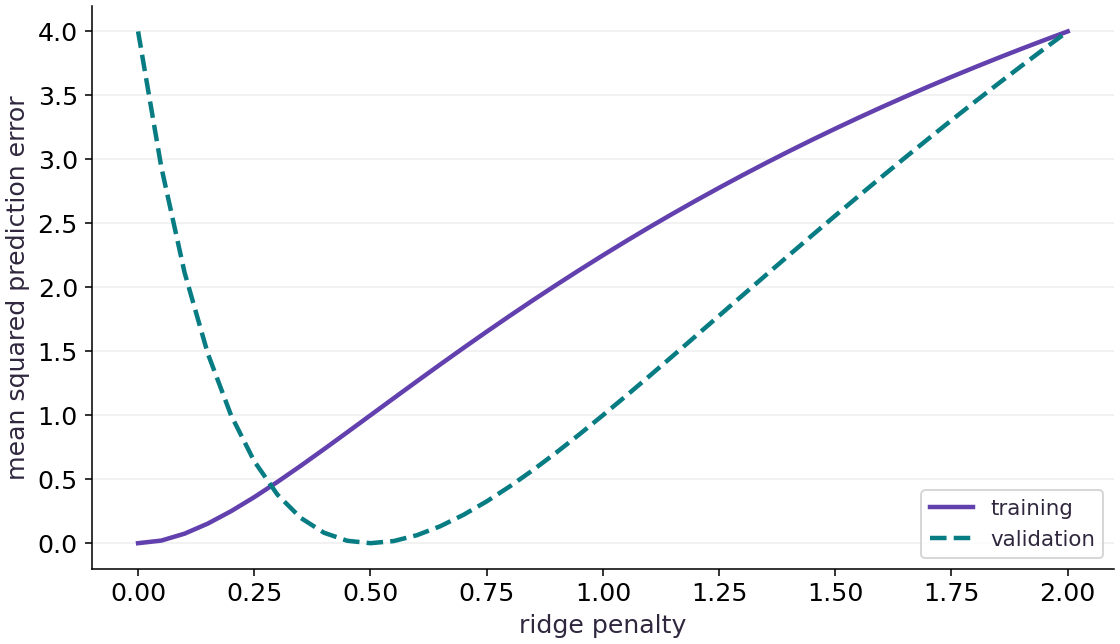

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis varies the ridge penalty $\lambda$. For each penalty, the model is fitted again. The vertical axis shows mean squared prediction error on training and validation data; it does not include the penalty term.

At $\lambda=0$, training error is zero and validation error is $4$. At $\lambda=0.5$, training error rises to $1$, but validation error falls to zero. Increasing the penalty to $2$ makes both errors $4$. The validation curve therefore has a minimum between the extremes.

### Connect it to the computation

The fitted weight is $w=3/(1+\lambda)$. The training targets favor slope $3$, while the validation targets in this constructed example favor slope $2$. Moderate shrinkage moves the model toward the validation relationship; too much shrinkage moves it past that relationship and toward underfitting.

Select the penalty using the validation minimum, not the intersection of the curves or the smallest training error. Here that choice is $0.5$. A zero validation error is a property of this tiny synthetic example, not a promise that regularization removes all error on real data.

## Sweep the penalty

Predict: Will the penalty with the lowest training error also have the lowest validation error?

In [7]:
# Experiment — Sweep the penalty: Regularization deliberately trades training fit against a...
# Initialize array `candidates` with explicit values and shape.
candidates = jnp.array([0.0, 0.5, 2.0])
# Combine or mask array elements to form `fits`.
fits = jnp.stack([ridge(X, y, float(a)) for a in candidates])
# Initialize array `training` with explicit values and shape.
training = jnp.array([mse(a, X, y) for a in fits])
# Initialize array `validation` with explicit values and shape.
validation = jnp.array([mse(a, Xv, yv) for a in fits])
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(fits[:, 0], jnp.array([3.0, 2.0, 1.0]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(training, jnp.array([0.0, 1.0, 4.0]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(validation, jnp.array([4.0, 0.0, 4.0]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert int(jnp.argmin(training)) != int(jnp.argmin(validation))
# Print the observed values to compare against the expected result.
print('penalty / train / validation:', candidates, training, validation)

penalty / train / validation: [0.  0.5 2. ] [0. 1. 4.] [4. 0. 4.]


Expected: Validation selects $\lambda=0.5$; training error prefers $\lambda=0$.

Regularization deliberately trades training fit against a preference for smaller weights.

## Duplicate the training set

Predict: If every training example is repeated, should the same mean-loss objective choose different weights?

In [8]:
# Experiment — Duplicate the training set: Using a mean data loss keeps the penalty tradeoff unchanged...
repeat = ridge(jnp.tile(X, (2, 1)), jnp.tile(y, 2), lam)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(repeat, w, atol=1e-06)

Expected: The weights stay fixed.

Using a mean data loss keeps the penalty tradeoff unchanged under exact dataset duplication.

## Your exercise

For a target slope of $4$ and penalty $\lambda=1$, derive the fitted slope and verify its gradient.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.zeros / jnp.ones(shape, dtype=...)` — Allocates a tensor of the given `shape` initialized with constants.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.

**Step-by-step implementation plan:**
1. Initialize array `y4` with explicit values and shape.
2. Run `ridge` to compute `w4`.
3. Verify that the numerical values match the expected reference within tolerance.
4. Verify that the output satisfies the expected shape, finite-value, or numerical contract.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: For a target slope of 4 and penalty \lambda=1, derive the fitted slope...
# Initialize array `y4` with explicit values and shape.
y4 = jnp.array(...)  # TODO: compute y4
# Run `ridge` to compute `w4`.
w4 = ridge(...)  # TODO: compute w4
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(w4, jnp.array([2.0]))  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jax.grad(lambda z: mse(z, X, y4) + jnp.dot(z, z))(w4), jnp.zeros(1), atol=1e-06)  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: For a target slope of 4 and penalty \lambda=1, derive the fitted slope...
# Initialize array `y4` with explicit values and shape.
# y4 = jnp.array(...)  # TODO: compute y4
# Run `ridge` to compute `w4`.
# w4 = ridge(...)  # TODO: compute w4
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(w4, jnp.array([2.0]))  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.allclose(jax.grad(lambda z: mse(z, X, y4) + jnp.dot(z, z))(w4), jnp.zeros(1), atol=1e-06)  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: For a target slope of 4 and penalty \lambda=1, derive the fitted slope...
# Initialize array `y4` with explicit values and shape.
y4 = jnp.array([-4.0, 4.0])
# Run `ridge` to compute `w4`.
w4 = ridge(X, y4, 1.0)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(w4, jnp.array([2.0]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jax.grad(lambda z: mse(z, X, y4) + jnp.dot(z, z))(w4), jnp.zeros(1), atol=1e-06)

## Do not accidentally shrink the intercept · Transfer / diagnosis

Fit constant targets $(5,5,5)$ using inputs $(-1,0,1)$ and a bias. Compare penalizing only the slope with penalizing both parameters at $\lambda=1$.

Hint: Use a diagonal mask $\operatorname{diag}(1,0)$.

### How to write: Do not accidentally shrink the intercept — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.zeros / jnp.ones(shape, dtype=...)` — Allocates a tensor of the given `shape` initialized with constants.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Initialize array `x` with explicit values and shape.
2. Initialize array `A` with explicit values and shape.
3. Initialize array `target` with explicit values and shape.
4. Initialize array `mask` with explicit values and shape.
5. Perform matrix contraction / projection to compute `correct`.

**Starter code scaffold (fill in the TODOs):**

```python
# Do not accidentally shrink the intercept (Transfer / diagnosis): The mask expresses a modeling choice: shrink feature effects...
# Initialize array `x` with explicit values and shape.
x = jnp.array(...)  # TODO: compute x
# Initialize array `A` with explicit values and shape.
A = jnp.stack(...)  # TODO: compute A
# Initialize array `target` with explicit values and shape.
target = jnp.full(...)  # TODO: compute target
# Initialize array `mask` with explicit values and shape.
mask = jnp.diag(...)  # TODO: compute mask
# Perform matrix contraction / projection to compute `correct`.
correct = jnp.linalg.solve(...)  # TODO: compute correct
# Run `ridge` to compute `all_penalized`.
all_penalized = ridge(...)  # TODO: compute all_penalized
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(correct, jnp.array([0.0, 5.0]))  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(all_penalized, jnp.array([0.0, 2.5]))  # TODO: complete assertion check
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Do not accidentally shrink the intercept (Transfer / diagnosis): The mask expresses a modeling choice: shrink feature effects...
# Initialize array `x` with explicit values and shape.
# x = jnp.array(...)  # TODO: compute x
# Initialize array `A` with explicit values and shape.
# A = jnp.stack(...)  # TODO: compute A
# Initialize array `target` with explicit values and shape.
# target = jnp.full(...)  # TODO: compute target
# Initialize array `mask` with explicit values and shape.
# mask = jnp.diag(...)  # TODO: compute mask
# Perform matrix contraction / projection to compute `correct`.
# correct = jnp.linalg.solve(...)  # TODO: compute correct
# Run `ridge` to compute `all_penalized`.
# all_penalized = ridge(...)  # TODO: compute all_penalized
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(correct, jnp.array([0.0, 5.0]))  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.allclose(all_penalized, jnp.array([0.0, 2.5]))  # TODO: complete assertion check

## Reference reasoning

The mask expresses a modeling choice: shrink feature effects while preserving the constant target level.

In [12]:
# Do not accidentally shrink the intercept (Transfer / diagnosis): The mask expresses a modeling choice: shrink feature effects...
# Initialize array `x` with explicit values and shape.
x = jnp.array([-1.0, 0.0, 1.0])
# Initialize array `A` with explicit values and shape.
A = jnp.stack([x, jnp.ones_like(x)], axis=1)
# Initialize array `target` with explicit values and shape.
target = jnp.full((3,), 5.0)
# Initialize array `mask` with explicit values and shape.
mask = jnp.diag(jnp.array([1.0, 0.0]))
# Perform matrix contraction / projection to compute `correct`.
correct = jnp.linalg.solve(A.T @ A + 3 * mask, A.T @ target)
# Run `ridge` to compute `all_penalized`.
all_penalized = ridge(A, target, 1.0)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(correct, jnp.array([0.0, 5.0]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(all_penalized, jnp.array([0.0, 2.5]))

## Catch preprocessing leakage · Transfer / diagnosis

Training inputs are $(0,2)$ and validation input is $100$. Compare training-only centering with centering all inputs together. Which can be reused for a truly unseen example?

Hint: Fit the mean on training data; do not refit it on validation data.

### How to write: Catch preprocessing leakage — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Initialize array `train_x` with explicit values and shape.
2. Initialize array `val_x` with explicit values and shape.
3. Aggregate array values to compute `train_mean`.
4. Aggregate array values to compute `leaked_mean`.
5. Verify that the numerical values match the expected reference within tolerance.

**Starter code scaffold (fill in the TODOs):**

```python
# Catch preprocessing leakage (Transfer / diagnosis): Validation data must not influence fitted preprocessing.
# Initialize array `train_x` with explicit values and shape.
train_x = jnp.array(...)  # TODO: compute train_x
# Initialize array `val_x` with explicit values and shape.
val_x = jnp.array(...)  # TODO: compute val_x
# Aggregate array values to compute `train_mean`.
train_mean = jnp.mean(...)  # TODO: compute train_mean
# Aggregate array values to compute `leaked_mean`.
leaked_mean = jnp.mean(...)  # TODO: compute leaked_mean
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(val_x - train_mean, jnp.array([99.0]))  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert not jnp.allclose(train_mean, leaked_mean)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.mean(train_x - train_mean), 0.0)  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Catch preprocessing leakage (Transfer / diagnosis): Validation data must not influence fitted preprocessing.
# Initialize array `train_x` with explicit values and shape.
# train_x = jnp.array(...)  # TODO: compute train_x
# Initialize array `val_x` with explicit values and shape.
# val_x = jnp.array(...)  # TODO: compute val_x
# Aggregate array values to compute `train_mean`.
# train_mean = jnp.mean(...)  # TODO: compute train_mean
# Aggregate array values to compute `leaked_mean`.
# leaked_mean = jnp.mean(...)  # TODO: compute leaked_mean
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(val_x - train_mean, jnp.array([99.0]))  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert not jnp.allclose(train_mean, leaked_mean)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.allclose(jnp.mean(train_x - train_mean), 0.0)  # TODO: complete assertion check

## Reference reasoning

Validation data must not influence fitted preprocessing. Reusing training statistics preserves the meaning of held-out evaluation.

In [14]:
# Catch preprocessing leakage (Transfer / diagnosis): Validation data must not influence fitted preprocessing.
# Initialize array `train_x` with explicit values and shape.
train_x = jnp.array([0.0, 2.0])
# Initialize array `val_x` with explicit values and shape.
val_x = jnp.array([100.0])
# Aggregate array values to compute `train_mean`.
train_mean = jnp.mean(train_x)
# Aggregate array values to compute `leaked_mean`.
leaked_mean = jnp.mean(jnp.concatenate([train_x, val_x]))
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(val_x - train_mean, jnp.array([99.0]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert not jnp.allclose(train_mean, leaked_mean)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.mean(train_x - train_mean), 0.0)

## Checkpoint

Which loss should select the penalty in this exercise?

1. The penalized training objective alone
2. Unpenalized validation prediction loss
3. A repeatedly inspected final test loss

## Diagnose

If increasing $\lambda$ improves the penalized objective but worsens predictions, check which quantity is being compared. Inspect the mean-versus-sum convention, bias mask, feature units and where preprocessing statistics were fitted.

## Evidence

Keep the ridge gradient/solve comparison, penalty sweep with separate train/validation losses, duplication check and bias-mask repair.

## Carry forward

- Regularization deliberately trades training fit against a preference for smaller weights.
- Using a mean data loss keeps the penalty tradeoff unchanged under exact dataset duplication.

## Primary references

- [Stanford CS229 notes: regularization and model selection](https://cs229.stanford.edu/notes2022fall/main_notes.pdf)
- [JAX linear solve](https://docs.jax.dev/en/latest/_autosummary/jax.numpy.linalg.solve.html)